<a href="https://colab.research.google.com/github/Maryvictor/mega-sena-astrologia-ml/blob/v1-antes-vedica/loucura.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Carregando o arquivo Excel
caminho_arquivo = '/content/Mega-Sena.xlsx'
df = pd.read_excel(caminho_arquivo)

# Exibindo as primeiras linhas do DataFrame original
display(df.head())

,Concurso,Data do Sorteio,Bola1,Bola2,Bola3,Bola4,Bola5,Bola6,Ganhadores 6 acertos,Cidade / UF,Rateio 6 acertos,Ganhadores 5 acertos,Rateio 5 acertos,Ganhadores 4 acertos,Rateio 4 acertos,Acumulado 6 acertos,Arrecadação Total,Estimativa prêmio,Acumulado Sorteio Especial Mega da Virada,Observação
0,1,11/03/1996,4,5,30,33,41,52,0,NaN,"R$0,00",17,"R$39.158,92",2016,"R$330,21","R$1.714.650,23","R$0,00","R$0,00","R$0,00",NaN
1,2,18/03/1996,9,37,39,41,43,49,1,PR,"R$2.307.162,23",65,"R$14.424,02",4488,"R$208,91","R$0,00","R$0,00","R$0,00","R$0,00",NaN
2,3,25/03/1996,10,11,29,30,36,47,2,RN; SP,"R$391.192,51",62,"R$10.515,93",4261,"R$153,01","R$0,00","R$0,00","R$0,00","R$0,00",NaN
3,4,01/04/1996,1,5,6,27,42,59,0,NaN,"R$0,00",39,"R$15.322,24",3311,"R$180,48","R$717.080,75","R$0,00","R$0,00","R$0,00",NaN
4,5,08/04/1996,1,2,6,16,19,46,0,NaN,"R$0,00",98,"R$5.318,10",5399,"R$96,53","R$1.342.488,85","R$0,00","R$0,00","R$0,00",NaN


In [ ]:
# Selecionando apenas as colunas desejadas (Concurso, Data e as 6 dezenas)
colunas_desejadas = ['Concurso', 'Data do Sorteio', 'Bola1', 'Bola2', 'Bola3', 'Bola4', 'Bola5', 'Bola6']
df_filtrado = df[colunas_desejadas]

# Exibindo o DataFrame filtrado
display(df_filtrado.head())

,Concurso,Data do Sorteio,Bola1,Bola2,Bola3,Bola4,Bola5,Bola6
0,1,11/03/1996,4,5,30,33,41,52
1,2,18/03/1996,9,37,39,41,43,49
2,3,25/03/1996,10,11,29,30,36,47
3,4,01/04/1996,1,5,6,27,42,59
4,5,08/04/1996,1,2,6,16,19,46


In [ ]:
# Uma linha por concurso (cada concurso tem um único mapa astral)
df_mega = df_filtrado[['Concurso', 'Data do Sorteio']].copy()

# As 6 bolas viram colunas dezena_1 ... dezena_60 (1 = foi sorteada, 0 = não foi)
bolas = df_filtrado.melt(
    id_vars='Concurso',
    value_vars=['Bola1', 'Bola2', 'Bola3', 'Bola4', 'Bola5', 'Bola6'],
    value_name='dezena'
)
dezenas = pd.get_dummies(bolas['dezena'], prefix='dezena', dtype=int).groupby(bolas['Concurso']).max()

df_mega = df_mega.merge(dezenas, left_on='Concurso', right_index=True)
df_mega = df_mega.sort_values(by='Concurso').reset_index(drop=True)

# Conferência: 1 linha por concurso e exatamente 6 dezenas marcadas em cada um
cols_dezena = [c for c in df_mega.columns if c.startswith('dezena_')]
print(df_mega.shape, '| somas por linha:', df_mega[cols_dezena].sum(axis=1).unique())
display(df_mega.head(5))

(3065, 62) | somas por linha: [6]


,Concurso,Data do Sorteio,dezena_1,dezena_2,dezena_3,dezena_4,dezena_5,dezena_6,dezena_7,dezena_8,dezena_9,dezena_10,dezena_11,dezena_12,dezena_13,dezena_14,dezena_15,dezena_16,dezena_17,dezena_18,dezena_19,dezena_20,dezena_21,dezena_22,dezena_23,dezena_24,dezena_25,dezena_26,dezena_27,dezena_28,dezena_29,dezena_30,dezena_31,dezena_32,dezena_33,dezena_34,dezena_35,dezena_36,dezena_37,dezena_38,dezena_39,dezena_40,dezena_41,dezena_42,dezena_43,dezena_44,dezena_45,dezena_46,dezena_47,dezena_48,dezena_49,dezena_50,dezena_51,dezena_52,dezena_53,dezena_54,dezena_55,dezena_56,dezena_57,dezena_58,dezena_59,dezena_60
0,1,11/03/1996,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1,2,18/03/1996,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,3,25/03/1996,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,4,01/04/1996,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,5,08/04/1996,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
pip install pyswisseph

In [ ]:
import swisseph as swe
from datetime import datetime
from zoneinfo import ZoneInfo

# Lista com os nomes dos signos do zodíaco na ordem astrológica tradicional
signos = [
    'Áries', 'Touro', 'Gêmeos', 'Câncer', 'Leão', 'Virgem',
    'Libra', 'Escorpião', 'Sagitário', 'Capricórnio', 'Aquário', 'Peixes'
]

def obter_signo_grau(longitude_astronomica):
    """Converte a longitude de 0 a 360 em signo e grau específico"""
    id_signo = int(longitude_astronomica // 30)
    grau = longitude_astronomica % 30
    nome_signo = signos[id_signo]
    return nome_signo, grau

# 1. Definir os dados de nascimento da Maria (10 de Maio de 1992, às 14:30 em São Paulo)
data_local = datetime(1992, 8, 16, 15, 45, tzinfo=ZoneInfo("America/Sao_Paulo"))

# 2. Converter a hora local para UTC (necessário para os cálculos do Swiss Ephemeris)
data_utc = data_local.astimezone(ZoneInfo("UTC"))

# 3. Calcular o Tempo Juliano (Julian Day) em UTC
ano, mes, dia = data_utc.year, data_utc.month, data_utc.day
hora_decimal = data_utc.hour + data_utc.minute / 60.0 + data_utc.second / 3600.0

julian_day = swe.julday(ano, mes, dia, hora_decimal)
print(f"Data de Nascimento (UTC): {data_utc}")
print(f"Julian Day calculado: {julian_day}\n")

# 4. Calcular a posição do Sol (swe.SUN = 0)
res_sol, ret_sol = swe.calc_ut(julian_day, swe.SUN)
lon_sol = res_sol[0]  # Longitude eclíptica
signo_sol, grau_sol = obter_signo_grau(lon_sol)
print(f"Sol: {grau_sol:.2f}° de {signo_sol} (Longitude total: {lon_sol:.2f}°)")

# 5. Calcular a posição da Lua (swe.MOON = 1)
res_lua, ret_lua = swe.calc_ut(julian_day, swe.MOON)
lon_lua = res_lua[0]  # Longitude eclíptica
signo_lua, grau_lua = obter_signo_grau(lon_lua)
print(f"Lua: {grau_lua:.2f}° de {signo_lua} (Longitude total: {lon_lua:.2f}°)")

Data de Nascimento (UTC): 1992-08-16 18:45:00+00:00
Julian Day calculado: 2448851.28125

Sol: 24.13° de Leão (Longitude total: 144.13°)
Lua: 0.78° de Áries (Longitude total: 0.78°)


In [ ]:
import pandas as pd

# 1. Garantir que a coluna 'Data do Sorteio' esteja no formato datetime
# Usamos errors='coerce' por segurança e indicamos o formato dia/mês/ano
df_mega['Data do Sorteio'] = pd.to_datetime(df_mega['Data do Sorteio'], format='%d/%m/%Y', errors='coerce')

# 2. Criar a função para determinar o horário com base nas regras informadas
def definir_horario(row):
    data = row['Data do Sorteio']

    if pd.isna(data):
        return None

    # Regra: A partir de julho/2026 nos domingos -> 11h
    # dayofweek == 6 representa o Domingo no pandas
    if data >= pd.Timestamp('2026-07-01') and data.dayofweek == 6:
        return '11h'

    # Regra: A partir de 03/11/2025 -> 21h
    elif data >= pd.Timestamp('2025-11-03'):
        return '21h'

    # Regra padrão: 1996 até 02/11/2025 -> 20h
    else:
        return '20h'

# 3. Aplicar a função para criar a coluna de horário
df_mega['horario'] = df_mega.apply(definir_horario, axis=1)

# 4. Criar a coluna de localidade de hora (ajustado para America/Sao_Paulo)
df_mega['local_hora'] = 'America/Sao_Paulo'

# Exibir uma amostra dos dados para ver se as colunas foram preenchidas corretamente
print("Amostra dos dados atualizados:")
display(df_mega.head(10))

# Vamos buscar especificamente um sorteio de domingo após julho de 2026 para validar
domingos_julho_2026 = df_mega[(df_mega['Data do Sorteio'] >= '2026-07-01') & (df_mega['Data do Sorteio'].dt.dayofweek == 6)]
if not domingos_julho_2026.empty:
    print("\nAmostra de sorteio de Domingo a partir de Julho/2026 (deve exibir 11h):")
    display(domingos_julho_2026.head(2))

Amostra dos dados atualizados:


,Concurso,Data do Sorteio,dezena_1,dezena_2,dezena_3,dezena_4,dezena_5,dezena_6,dezena_7,dezena_8,dezena_9,dezena_10,dezena_11,dezena_12,dezena_13,dezena_14,dezena_15,dezena_16,dezena_17,dezena_18,dezena_19,dezena_20,dezena_21,dezena_22,dezena_23,dezena_24,dezena_25,dezena_26,dezena_27,dezena_28,dezena_29,dezena_30,dezena_31,dezena_32,dezena_33,dezena_34,dezena_35,dezena_36,dezena_37,dezena_38,dezena_39,dezena_40,dezena_41,dezena_42,dezena_43,dezena_44,dezena_45,dezena_46,dezena_47,dezena_48,dezena_49,dezena_50,dezena_51,dezena_52,dezena_53,dezena_54,dezena_55,dezena_56,dezena_57,dezena_58,dezena_59,dezena_60,horario,local_hora
0,1,1996-03-11,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,20h,America/Sao_Paulo
1,2,1996-03-18,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,20h,America/Sao_Paulo
2,3,1996-03-25,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,20h,America/Sao_Paulo
3,4,1996-04-01,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,20h,America/Sao_Paulo
4,5,1996-04-08,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,20h,America/Sao_Paulo
5,6,1996-04-15,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,20h,America/Sao_Paulo
6,7,1996-04-22,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,20h,America/Sao_Paulo
7,8,1996-04-29,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,20h,America/Sao_Paulo
8,9,1996-05-06,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,1,20h,America/Sao_Paulo
9,10,1996-05-13,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,20h,America/Sao_Paulo



Amostra de sorteio de Domingo a partir de Julho/2026 (deve exibir 11h):


,Concurso,Data do Sorteio,dezena_1,dezena_2,dezena_3,dezena_4,dezena_5,dezena_6,dezena_7,dezena_8,dezena_9,dezena_10,dezena_11,dezena_12,dezena_13,dezena_14,dezena_15,dezena_16,dezena_17,dezena_18,dezena_19,dezena_20,dezena_21,dezena_22,dezena_23,dezena_24,dezena_25,dezena_26,dezena_27,dezena_28,dezena_29,dezena_30,dezena_31,dezena_32,dezena_33,dezena_34,dezena_35,dezena_36,dezena_37,dezena_38,dezena_39,dezena_40,dezena_41,dezena_42,dezena_43,dezena_44,dezena_45,dezena_46,dezena_47,dezena_48,dezena_49,dezena_50,dezena_51,dezena_52,dezena_53,dezena_54,dezena_55,dezena_56,dezena_57,dezena_58,dezena_59,dezena_60,horario,local_hora
3032,3033,2026-07-19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,11h,America/Sao_Paulo
3035,3036,2026-07-26,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,11h,America/Sao_Paulo


In [ ]:
df_mega.tail(30)

,Concurso,Data do Sorteio,dezena_1,dezena_2,dezena_3,dezena_4,dezena_5,dezena_6,dezena_7,dezena_8,dezena_9,dezena_10,dezena_11,dezena_12,dezena_13,dezena_14,dezena_15,dezena_16,dezena_17,dezena_18,dezena_19,dezena_20,dezena_21,dezena_22,dezena_23,dezena_24,dezena_25,dezena_26,dezena_27,dezena_28,dezena_29,dezena_30,dezena_31,dezena_32,dezena_33,dezena_34,dezena_35,dezena_36,dezena_37,dezena_38,dezena_39,dezena_40,dezena_41,dezena_42,dezena_43,dezena_44,dezena_45,dezena_46,dezena_47,dezena_48,dezena_49,dezena_50,dezena_51,dezena_52,dezena_53,dezena_54,dezena_55,dezena_56,dezena_57,dezena_58,dezena_59,dezena_60,horario,local_hora
3035,3036,2026-07-26,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,11h,America/Sao_Paulo
3036,3037,2026-07-28,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,21h,America/Sao_Paulo
3037,3038,2026-07-30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,21h,America/Sao_Paulo
3038,3039,2026-08-02,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,11h,America/Sao_Paulo
3039,3040,2026-08-04,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,21h,America/Sao_Paulo
3040,3041,2026-08-06,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,21h,America/Sao_Paulo
3041,3042,2026-08-09,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,11h,America/Sao_Paulo
3042,3043,2026-08-11,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,21h,America/Sao_Paulo
3043,3044,2026-08-13,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,21h,America/Sao_Paulo
3044,3045,2026-08-16,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,11h,America/Sao_Paulo


In [ ]:
import pandas as pd
import swisseph as swe
from datetime import datetime
from zoneinfo import ZoneInfo

# Lista de corpos celestes e seus respectivos códigos na swisseph
corpos = {
    'Sol': swe.SUN,
    'Lua': swe.MOON,
    'Mercurio': swe.MERCURY,
    'Venus': swe.VENUS,
    'Marte': swe.MARS,
    'Jupiter': swe.JUPITER,
    'Saturno': swe.SATURN,
    'Urano': swe.URANUS,
    'Netuno': swe.NEPTUNE,
    'Plutao': swe.PLUTO
}

signos = [
    'Áries', 'Touro', 'Gêmeos', 'Câncer', 'Leão', 'Virgem',
    'Libra', 'Escorpião', 'Sagitário', 'Capricórnio', 'Aquário', 'Peixes'
]

def obter_signo(longitude_astronomica):
    id_signo = int(longitude_astronomica // 30)
    return signos[id_signo]

# 1. Criar chaves únicas de data e horário para evitar recalcular a mesma configuração planetária 6 vezes
df_datas_unicas = df_mega[['Data do Sorteio', 'horario']].drop_duplicates().copy()

# Função para calcular os signos dos planetas para um determinado momento (Data + Horário em SP)
def calcular_posicoes_momento(row):
    data = row['Data do Sorteio']
    horario_str = row['horario']

    if pd.isna(data) or pd.isna(horario_str):
        return {corpo: None for corpo in corpos}

    # Extrair hora inteira do texto (ex: '20h' -> 20, '11h' -> 11)
    hora = int(horario_str.replace('h', ''))

    # Definir data/hora local em São Paulo
    data_local = datetime(data.year, data.month, data.day, hora, 0, tzinfo=ZoneInfo("America/Sao_Paulo"))
    # Converter para UTC
    data_utc = data_local.astimezone(ZoneInfo("UTC"))

    # Calcular Julian Day em UTC
    hora_decimal = data_utc.hour + data_utc.minute / 60.0 + data_utc.second / 3600.0
    julian_day = swe.julday(data_utc.year, data_utc.month, data_utc.day, hora_decimal)

    resultado_linha = {}
    for nome_corpo, codigo_corpo in corpos.items():
        res, _ = swe.calc_ut(julian_day, codigo_corpo)
        longitude = res[0]
        resultado_linha[nome_corpo] = obter_signo(longitude)

    return resultado_linha

print("Calculando o mapa astrológico de cada sorteio... (Isso pode levar alguns segundos)")
# Aplicar os cálculos astrológicos nas datas únicas
posicoes_calculadas = df_datas_unicas.apply(calcular_posicoes_momento, axis=1)

# Expandir o dicionário de resultados em novas colunas no df_datas_unicas
df_posicoes_expandidas = pd.DataFrame(posicoes_calculadas.tolist(), index=df_datas_unicas.index)
df_datas_com_astros = pd.concat([df_datas_unicas, df_posicoes_expandidas], axis=1)

# 2. Mesclar de volta as informações no DataFrame longo principal
df_mega = df_mega.merge(df_datas_com_astros, on=['Data do Sorteio', 'horario'], how='left')

print("Processamento concluído!")
display(df_mega.tail(10))

Calculando o mapa astrológico de cada sorteio... (Isso pode levar alguns segundos)
Processamento concluído!


,Concurso,Data do Sorteio,dezena_1,dezena_2,dezena_3,dezena_4,dezena_5,dezena_6,dezena_7,dezena_8,dezena_9,dezena_10,dezena_11,dezena_12,dezena_13,dezena_14,dezena_15,dezena_16,dezena_17,dezena_18,dezena_19,dezena_20,dezena_21,dezena_22,dezena_23,dezena_24,dezena_25,dezena_26,dezena_27,dezena_28,dezena_29,dezena_30,dezena_31,dezena_32,dezena_33,dezena_34,dezena_35,dezena_36,dezena_37,dezena_38,dezena_39,dezena_40,dezena_41,dezena_42,dezena_43,dezena_44,dezena_45,dezena_46,dezena_47,dezena_48,dezena_49,dezena_50,dezena_51,dezena_52,dezena_53,dezena_54,dezena_55,dezena_56,dezena_57,dezena_58,dezena_59,dezena_60,horario,local_hora,Sol,Lua,Mercurio,Venus,Marte,Jupiter,Saturno,Urano,Netuno,Plutao
3055,3056,2026-09-10,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,21h,America/Sao_Paulo,Virgem,Virgem,Libra,Escorpião,Câncer,Leão,Áries,Gêmeos,Áries,Aquário
3056,3057,2026-09-13,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,11h,America/Sao_Paulo,Virgem,Libra,Libra,Escorpião,Câncer,Leão,Áries,Gêmeos,Áries,Aquário
3057,3058,2026-09-15,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,21h,America/Sao_Paulo,Virgem,Escorpião,Libra,Escorpião,Câncer,Leão,Áries,Gêmeos,Áries,Aquário
3058,3059,2026-09-17,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,21h,America/Sao_Paulo,Virgem,Sagitário,Libra,Escorpião,Câncer,Leão,Áries,Gêmeos,Áries,Aquário
3059,3060,2026-09-20,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11h,America/Sao_Paulo,Virgem,Capricórnio,Libra,Escorpião,Câncer,Leão,Áries,Gêmeos,Áries,Aquário
3060,3061,2026-09-22,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,21h,America/Sao_Paulo,Virgem,Aquário,Libra,Escorpião,Câncer,Leão,Áries,Gêmeos,Áries,Aquário
3061,3062,2026-09-24,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,21h,America/Sao_Paulo,Libra,Peixes,Libra,Escorpião,Câncer,Leão,Áries,Gêmeos,Áries,Aquário
3062,3063,2026-09-27,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,11h,America/Sao_Paulo,Libra,Áries,Libra,Escorpião,Câncer,Leão,Áries,Gêmeos,Áries,Aquário
3063,3064,2026-09-29,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,21h,America/Sao_Paulo,Libra,Touro,Libra,Escorpião,Leão,Leão,Áries,Gêmeos,Áries,Aquário
3064,3065,2026-10-01,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,21h,America/Sao_Paulo,Libra,Gêmeos,Escorpião,Escorpião,Leão,Leão,Áries,Gêmeos,Áries,Aquário


In [ ]:
import os
import urllib.request
import pandas as pd
import swisseph as swe
from datetime import datetime
from zoneinfo import ZoneInfo

# ---------------------------------------------------------------
# 0. Arquivo de efeméride (necessário para Quíron)
#    Baixa uma vez só e fica guardado na pasta "ephe"
# ---------------------------------------------------------------
PASTA_EPHE = os.path.abspath("ephe")
os.makedirs(PASTA_EPHE, exist_ok=True)
URL_BASE = "https://raw.githubusercontent.com/aloistr/swisseph/master/ephe/"
for arquivo in ["seas_18.se1", "sepl_18.se1", "semo_18.se1"]:
    destino = os.path.join(PASTA_EPHE, arquivo)
    if not os.path.exists(destino):
        print(f"Baixando {arquivo}...")
        urllib.request.urlretrieve(URL_BASE + arquivo, destino)
swe.set_ephe_path(PASTA_EPHE)

# ---------------------------------------------------------------
# 1. Configurações
# ---------------------------------------------------------------
LATITUDE_SP = -23.5505
LONGITUDE_SP = -46.6333
FUSO = ZoneInfo("America/Sao_Paulo")

corpos = {
    'Sol': swe.SUN,
    'Lua': swe.MOON,
    'Mercurio': swe.MERCURY,
    'Venus': swe.VENUS,
    'Marte': swe.MARS,
    'Jupiter': swe.JUPITER,
    'Saturno': swe.SATURN,
    'Urano': swe.URANUS,
    'Netuno': swe.NEPTUNE,
    'Plutao': swe.PLUTO,
    'Quiron': swe.CHIRON,
    'Lilith': swe.MEAN_APOG,      # Lilith Média (era o 30, que não existe)
    'Nodo_Norte': swe.MEAN_NODE,  # Nodo Lunar Médio
}

signos = ['Áries', 'Touro', 'Gêmeos', 'Câncer', 'Leão', 'Virgem',
          'Libra', 'Escorpião', 'Sagitário', 'Capricórnio', 'Aquário', 'Peixes']

COLUNAS_MAPA = list(corpos) + ['Nodo_Sul', 'Ascendente', 'Descendente', 'MC', 'IC']

def obter_signo(longitude):
    return signos[int((longitude % 360) // 30)]

# ---------------------------------------------------------------
# 2. Limpa o df_mega e garante que a data é data mesmo
# ---------------------------------------------------------------
colunas_originais = ['Concurso', 'Data do Sorteio', 'horario', 'local_hora'] + [c for c in df_mega.columns if c.startswith('dezena_')]
df_mega = df_mega[colunas_originais].copy()
df_mega['Data do Sorteio'] = pd.to_datetime(df_mega['Data do Sorteio'], dayfirst=True, errors='coerce')

df_datas_unicas = df_mega[['Data do Sorteio', 'horario']].drop_duplicates().copy()

# ---------------------------------------------------------------
# 3. Cálculo do mapa
# ---------------------------------------------------------------
def calcular_mapa_completo(row):
    data = row['Data do Sorteio']
    horario_str = row['horario']

    if pd.isna(data) or pd.isna(horario_str):
        return {col: None for col in COLUNAS_MAPA}

    hora = int(str(horario_str).lower().replace('h', '').strip())

    data_local = datetime(data.year, data.month, data.day, hora, 0, tzinfo=FUSO)
    data_utc = data_local.astimezone(ZoneInfo("UTC"))
    hora_decimal = data_utc.hour + data_utc.minute / 60 + data_utc.second / 3600
    julian_day = swe.julday(data_utc.year, data_utc.month, data_utc.day, hora_decimal)

    resultado = {}

    # A. Planetas, Quíron, Lilith e Nodos
    for nome, codigo in corpos.items():
        res, _ = swe.calc_ut(julian_day, codigo)
        resultado[nome] = obter_signo(res[0])
        if nome == 'Nodo_Norte':
            resultado['Nodo_Sul'] = obter_signo(res[0] + 180)

    # B. Ângulos (Placidus)
    cuspides, angulos = swe.houses(julian_day, LATITUDE_SP, LONGITUDE_SP, b'P')
    asc, mc = angulos[0], angulos[1]
    resultado['Ascendente'] = obter_signo(asc)
    resultado['Descendente'] = obter_signo(asc + 180)
    resultado['MC'] = obter_signo(mc)
    resultado['IC'] = obter_signo(mc + 180)

    return resultado

print("Calculando o mapa astrológico de cada sorteio...")
posicoes = df_datas_unicas.apply(calcular_mapa_completo, axis=1)
df_posicoes = pd.DataFrame(posicoes.tolist(), index=df_datas_unicas.index)
df_datas_com_astros = pd.concat([df_datas_unicas, df_posicoes], axis=1)

df_mega = df_mega.merge(df_datas_com_astros, on=['Data do Sorteio', 'horario'], how='left')

print("Pronto! Amostra final:")
display(df_mega.tail(10))


Calculando o mapa astrológico de cada sorteio...
Pronto! Amostra final:


,Concurso,Data do Sorteio,horario,local_hora,dezena_1,dezena_2,dezena_3,dezena_4,dezena_5,dezena_6,dezena_7,dezena_8,dezena_9,dezena_10,dezena_11,dezena_12,dezena_13,dezena_14,dezena_15,dezena_16,dezena_17,dezena_18,dezena_19,dezena_20,dezena_21,dezena_22,dezena_23,dezena_24,dezena_25,dezena_26,dezena_27,dezena_28,dezena_29,dezena_30,dezena_31,dezena_32,dezena_33,dezena_34,dezena_35,dezena_36,dezena_37,dezena_38,dezena_39,dezena_40,dezena_41,dezena_42,dezena_43,dezena_44,dezena_45,dezena_46,dezena_47,dezena_48,dezena_49,dezena_50,dezena_51,dezena_52,dezena_53,dezena_54,dezena_55,dezena_56,dezena_57,dezena_58,dezena_59,dezena_60,Sol,Lua,Mercurio,Venus,Marte,Jupiter,Saturno,Urano,Netuno,Plutao,Quiron,Lilith,Nodo_Norte,Nodo_Sul,Ascendente,Descendente,MC,IC
3055,3056,2026-09-10,21h,America/Sao_Paulo,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,Virgem,Virgem,Libra,Escorpião,Câncer,Leão,Áries,Gêmeos,Áries,Aquário,Touro,Sagitário,Aquário,Leão,Touro,Escorpião,Aquário,Leão
3056,3057,2026-09-13,11h,America/Sao_Paulo,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,Virgem,Libra,Libra,Escorpião,Câncer,Leão,Áries,Gêmeos,Áries,Aquário,Touro,Sagitário,Aquário,Leão,Sagitário,Gêmeos,Virgem,Peixes
3057,3058,2026-09-15,21h,America/Sao_Paulo,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,Virgem,Escorpião,Libra,Escorpião,Câncer,Leão,Áries,Gêmeos,Áries,Aquário,Touro,Capricórnio,Aquário,Leão,Touro,Escorpião,Aquário,Leão
3058,3059,2026-09-17,21h,America/Sao_Paulo,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Virgem,Sagitário,Libra,Escorpião,Câncer,Leão,Áries,Gêmeos,Áries,Aquário,Touro,Capricórnio,Aquário,Leão,Touro,Escorpião,Aquário,Leão
3059,3060,2026-09-20,11h,America/Sao_Paulo,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Virgem,Capricórnio,Libra,Escorpião,Câncer,Leão,Áries,Gêmeos,Áries,Aquário,Áries,Capricórnio,Aquário,Leão,Sagitário,Gêmeos,Virgem,Peixes
3060,3061,2026-09-22,21h,America/Sao_Paulo,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,Virgem,Aquário,Libra,Escorpião,Câncer,Leão,Áries,Gêmeos,Áries,Aquário,Áries,Capricórnio,Aquário,Leão,Touro,Escorpião,Aquário,Leão
3061,3062,2026-09-24,21h,America/Sao_Paulo,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Libra,Peixes,Libra,Escorpião,Câncer,Leão,Áries,Gêmeos,Áries,Aquário,Áries,Capricórnio,Aquário,Leão,Touro,Escorpião,Aquário,Leão
3062,3063,2026-09-27,11h,America/Sao_Paulo,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,Libra,Áries,Libra,Escorpião,Câncer,Leão,Áries,Gêmeos,Áries,Aquário,Áries,Capricórnio,Aquário,Leão,Capricórnio,Câncer,Virgem,Peixes
3063,3064,2026-09-29,21h,America/Sao_Paulo,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,Libra,Touro,Libra,Escorpião,Leão,Leão,Áries,Gêmeos,Áries,Aquário,Áries,Capricórnio,Aquário,Leão,Touro,Escorpião,Aquário,Leão
3064,3065,2026-10-01,21h,America/Sao_Paulo,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,Libra,Gêmeos,Escorpião,Escorpião,Leão,Leão,Áries,Gêmeos,Áries,Aquário,Áries,Capricórnio,Aquário,Leão,Touro,Escorpião,Aquário,Leão


In [ ]:
import pandas as pd

# Configura o pandas para exibir todas as colunas sem cortes
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Exibe as 5 primeiras linhas do DataFrame unificado
display(df_mega.head(5))

,Concurso,Data do Sorteio,horario,local_hora,dezena_1,dezena_2,dezena_3,dezena_4,dezena_5,dezena_6,dezena_7,dezena_8,dezena_9,dezena_10,dezena_11,dezena_12,dezena_13,dezena_14,dezena_15,dezena_16,dezena_17,dezena_18,dezena_19,dezena_20,dezena_21,dezena_22,dezena_23,dezena_24,dezena_25,dezena_26,dezena_27,dezena_28,dezena_29,dezena_30,dezena_31,dezena_32,dezena_33,dezena_34,dezena_35,dezena_36,dezena_37,dezena_38,dezena_39,dezena_40,dezena_41,dezena_42,dezena_43,dezena_44,dezena_45,dezena_46,dezena_47,dezena_48,dezena_49,dezena_50,dezena_51,dezena_52,dezena_53,dezena_54,dezena_55,dezena_56,dezena_57,dezena_58,dezena_59,dezena_60,Sol,Lua,Mercurio,Venus,Marte,Jupiter,Saturno,Urano,Netuno,Plutao,Quiron,Lilith,Nodo_Norte,Nodo_Sul,Ascendente,Descendente,MC,IC
0,1,1996-03-11,20h,America/Sao_Paulo,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,Peixes,Sagitário,Peixes,Touro,Peixes,Capricórnio,Peixes,Aquário,Capricórnio,Sagitário,Libra,Câncer,Libra,Áries,Libra,Áries,Câncer,Capricórnio
1,2,1996-03-18,20h,America/Sao_Paulo,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,Peixes,Peixes,Peixes,Touro,Peixes,Capricórnio,Peixes,Aquário,Capricórnio,Sagitário,Libra,Câncer,Libra,Áries,Escorpião,Touro,Câncer,Capricórnio
2,3,1996-03-25,20h,America/Sao_Paulo,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,Áries,Gêmeos,Áries,Touro,Áries,Capricórnio,Peixes,Aquário,Capricórnio,Sagitário,Libra,Câncer,Libra,Áries,Escorpião,Touro,Câncer,Capricórnio
3,4,1996-04-01,20h,America/Sao_Paulo,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,Áries,Virgem,Áries,Touro,Áries,Capricórnio,Peixes,Aquário,Capricórnio,Sagitário,Libra,Câncer,Libra,Áries,Escorpião,Touro,Leão,Aquário
4,5,1996-04-08,20h,America/Sao_Paulo,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Áries,Sagitário,Touro,Gêmeos,Áries,Capricórnio,Áries,Aquário,Capricórnio,Sagitário,Libra,Câncer,Libra,Áries,Escorpião,Touro,Leão,Aquário


In [ ]:
df.columns

Index(['Concurso', 'Data do Sorteio', 'Bola1', 'Bola2', 'Bola3', 'Bola4', 'Bola5', 'Bola6', 'Ganhadores 6 acertos', 'Cidade / UF', 'Rateio 6 acertos', 'Ganhadores 5 acertos', 'Rateio 5 acertos', 'Ganhadores 4 acertos', 'Rateio 4 acertos', 'Acumulado 6 acertos', 'Arrecadação Total', 'Estimativa prêmio', 'Acumulado Sorteio Especial Mega da Virada', 'Observação'], dtype='object')

In [ ]:
df_mega.columns

Index(['Concurso', 'Data do Sorteio', 'horario', 'local_hora', 'dezena_1', 'dezena_2', 'dezena_3', 'dezena_4', 'dezena_5', 'dezena_6', 'dezena_7', 'dezena_8', 'dezena_9', 'dezena_10', 'dezena_11', 'dezena_12', 'dezena_13', 'dezena_14', 'dezena_15', 'dezena_16', 'dezena_17', 'dezena_18', 'dezena_19', 'dezena_20', 'dezena_21', 'dezena_22', 'dezena_23', 'dezena_24', 'dezena_25', 'dezena_26', 'dezena_27', 'dezena_28', 'dezena_29', 'dezena_30', 'dezena_31', 'dezena_32', 'dezena_33', 'dezena_34', 'dezena_35', 'dezena_36', 'dezena_37', 'dezena_38', 'dezena_39', 'dezena_40', 'dezena_41', 'dezena_42', 'dezena_43', 'dezena_44', 'dezena_45', 'dezena_46', 'dezena_47', 'dezena_48', 'dezena_49', 'dezena_50', 'dezena_51', 'dezena_52', 'dezena_53', 'dezena_54', 'dezena_55', 'dezena_56', 'dezena_57', 'dezena_58', 'dezena_59', 'dezena_60', 'Sol', 'Lua', 'Mercurio', 'Venus', 'Marte', 'Jupiter', 'Saturno', 'Urano', 'Netuno', 'Plutao', 'Quiron', 'Lilith', 'Nodo_Norte', 'Nodo_Sul', 'Ascendente',
       'Des

In [ ]:
df_mega.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3065 entries, 0 to 3064
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Concurso         3065 non-null   int64         
 1   Data do Sorteio  3065 non-null   datetime64[ns]
 2   horario          3065 non-null   object        
 3   local_hora       3065 non-null   object        
 4   dezena_1         3065 non-null   int64         
 5   dezena_2         3065 non-null   int64         
 6   dezena_3         3065 non-null   int64         
 7   dezena_4         3065 non-null   int64         
 8   dezena_5         3065 non-null   int64         
 9   dezena_6         3065 non-null   int64         
 10  dezena_7         3065 non-null   int64         
 11  dezena_8         3065 non-null   int64         
 12  dezena_9         3065 non-null   int64         
 13  dezena_10        3065 non-null   int64         
 14  dezena_11        3065 non-null   int64  

In [ ]:
astros = ['Sol', 'Lua', 'Mercurio', 'Venus', 'Marte', 'Jupiter', 'Saturno', 'Urano', 'Netuno', 'Plutao', 'Quiron', 'Lilith', 'Nodo_Norte', 'Nodo_Sul', 'Ascendente', 'Descendente', 'MC', 'IC']

df_mega = pd.get_dummies(data=df_mega, columns=astros, dtype=int)

# Reordena as colunas: identificação, dezenas e, por fim, cada astro com os signos na ordem do zodíaco (Áries, Touro, Gêmeos, Câncer...)
cols_base = ['Concurso', 'Data do Sorteio', 'horario', 'local_hora'] + [c for c in df_mega.columns if c.startswith('dezena_')]
cols_astros = [f'{astro}_{signo}' for astro in astros for signo in signos if f'{astro}_{signo}' in df_mega.columns]
df_mega = df_mega[cols_base + cols_astros]

df_mega.head()

,Concurso,Data do Sorteio,horario,local_hora,dezena_1,dezena_2,dezena_3,dezena_4,dezena_5,dezena_6,dezena_7,dezena_8,dezena_9,dezena_10,dezena_11,dezena_12,dezena_13,dezena_14,dezena_15,dezena_16,dezena_17,dezena_18,dezena_19,dezena_20,dezena_21,dezena_22,dezena_23,dezena_24,dezena_25,dezena_26,dezena_27,dezena_28,dezena_29,dezena_30,dezena_31,dezena_32,dezena_33,dezena_34,dezena_35,dezena_36,dezena_37,dezena_38,dezena_39,dezena_40,dezena_41,dezena_42,dezena_43,dezena_44,dezena_45,dezena_46,dezena_47,dezena_48,dezena_49,dezena_50,dezena_51,dezena_52,dezena_53,dezena_54,dezena_55,dezena_56,dezena_57,dezena_58,dezena_59,dezena_60,Sol_Áries,Sol_Touro,Sol_Gêmeos,Sol_Câncer,Sol_Leão,Sol_Virgem,Sol_Libra,Sol_Escorpião,Sol_Sagitário,Sol_Capricórnio,Sol_Aquário,Sol_Peixes,Lua_Áries,Lua_Touro,Lua_Gêmeos,Lua_Câncer,Lua_Leão,Lua_Virgem,Lua_Libra,Lua_Escorpião,Lua_Sagitário,Lua_Capricórnio,Lua_Aquário,Lua_Peixes,Mercurio_Áries,Mercurio_Touro,Mercurio_Gêmeos,Mercurio_Câncer,Mercurio_Leão,Mercurio_Virgem,Mercurio_Libra,Mercurio_Escorpião,Mercurio_Sagitário,Mercurio_Capricórnio,Mercurio_Aquário,Mercurio_Peixes,Venus_Áries,Venus_Touro,Venus_Gêmeos,Venus_Câncer,Venus_Leão,Venus_Virgem,Venus_Libra,Venus_Escorpião,Venus_Sagitário,Venus_Capricórnio,Venus_Aquário,Venus_Peixes,Marte_Áries,Marte_Touro,Marte_Gêmeos,Marte_Câncer,Marte_Leão,Marte_Virgem,Marte_Libra,Marte_Escorpião,Marte_Sagitário,Marte_Capricórnio,Marte_Aquário,Marte_Peixes,Jupiter_Áries,Jupiter_Touro,Jupiter_Gêmeos,Jupiter_Câncer,Jupiter_Leão,Jupiter_Virgem,Jupiter_Libra,Jupiter_Escorpião,Jupiter_Sagitário,Jupiter_Capricórnio,Jupiter_Aquário,Jupiter_Peixes,Saturno_Áries,Saturno_Touro,Saturno_Gêmeos,Saturno_Câncer,Saturno_Leão,Saturno_Virgem,Saturno_Libra,Saturno_Escorpião,Saturno_Sagitário,Saturno_Capricórnio,Saturno_Aquário,Saturno_Peixes,Urano_Áries,Urano_Touro,Urano_Gêmeos,Urano_Aquário,Urano_Peixes,Netuno_Áries,Netuno_Capricórnio,Netuno_Aquário,Netuno_Peixes,Plutao_Sagitário,Plutao_Capricórnio,Plutao_Aquário,Quiron_Áries,Quiron_Touro,Quiron_Libra,Quiron_Escorpião,Quiron_Sagitário,Quiron_Capricórnio,Quiron_Aquário,Quiron_Peixes,Lilith_Áries,Lilith_Touro,Lilith_Gêmeos,Lilith_Câncer,Lilith_Leão,Lilith_Virgem,Lilith_Libra,Lilith_Escorpião,Lilith_Sagitário,Lilith_Capricórnio,Lilith_Aquário,Lilith_Peixes,Nodo_Norte_Áries,Nodo_Norte_Touro,Nodo_Norte_Gêmeos,Nodo_Norte_Câncer,Nodo_Norte_Leão,Nodo_Norte_Virgem,Nodo_Norte_Libra,Nodo_Norte_Escorpião,Nodo_Norte_Sagitário,Nodo_Norte_Capricórnio,Nodo_Norte_Aquário,Nodo_Norte_Peixes,Nodo_Sul_Áries,Nodo_Sul_Touro,Nodo_Sul_Gêmeos,Nodo_Sul_Câncer,Nodo_Sul_Leão,Nodo_Sul_Virgem,Nodo_Sul_Libra,Nodo_Sul_Escorpião,Nodo_Sul_Sagitário,Nodo_Sul_Capricórnio,Nodo_Sul_Aquário,Nodo_Sul_Peixes,Ascendente_Áries,Ascendente_Touro,Ascendente_Gêmeos,Ascendente_Câncer,Ascendente_Leão,Ascendente_Virgem,Ascendente_Libra,Ascendente_Escorpião,Ascendente_Sagitário,Ascendente_Capricórnio,Ascendente_Aquário,Ascendente_Peixes,Descendente_Áries,Descendente_Touro,Descendente_Gêmeos,Descendente_Câncer,Descendente_Leão,Descendente_Virgem,Descendente_Libra,Descendente_Escorpião,Descendente_Sagitário,Descendente_Capricórnio,Descendente_Aquário,Descendente_Peixes,MC_Áries,MC_Touro,MC_Gêmeos,MC_Câncer,MC_Leão,MC_Virgem,MC_Libra,MC_Escorpião,MC_Sagitário,MC_Capricórnio,MC_Aquário,MC_Peixes,IC_Áries,IC_Touro,IC_Gêmeos,IC_Câncer,IC_Leão,IC_Virgem,IC_Libra,IC_Escorpião,IC_Sagitário,IC_Capricórnio,IC_Aquário,IC_Peixes
0,1,1996-03-11,20h,America/Sao_Paulo,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,2,1996-03-18,20h,America/Sao_Paulo,0,0,0,0,0,0

In [ ]:
# As dezenas já foram transformadas em dezena_1 ... dezena_60 lá no começo (1 linha por concurso)
cols_dezena = [c for c in df_mega.columns if c.startswith('dezena_')]
print(df_mega.shape, '| somas por linha:', df_mega[cols_dezena].sum(axis=1).unique())
df_mega.head()

(3065, 252) | somas por linha: [6]


,Concurso,Data do Sorteio,horario,local_hora,dezena_1,dezena_2,dezena_3,dezena_4,dezena_5,dezena_6,dezena_7,dezena_8,dezena_9,dezena_10,dezena_11,dezena_12,dezena_13,dezena_14,dezena_15,dezena_16,dezena_17,dezena_18,dezena_19,dezena_20,dezena_21,dezena_22,dezena_23,dezena_24,dezena_25,dezena_26,dezena_27,dezena_28,dezena_29,dezena_30,dezena_31,dezena_32,dezena_33,dezena_34,dezena_35,dezena_36,dezena_37,dezena_38,dezena_39,dezena_40,dezena_41,dezena_42,dezena_43,dezena_44,dezena_45,dezena_46,dezena_47,dezena_48,dezena_49,dezena_50,dezena_51,dezena_52,dezena_53,dezena_54,dezena_55,dezena_56,dezena_57,dezena_58,dezena_59,dezena_60,Sol_Áries,Sol_Touro,Sol_Gêmeos,Sol_Câncer,Sol_Leão,Sol_Virgem,Sol_Libra,Sol_Escorpião,Sol_Sagitário,Sol_Capricórnio,Sol_Aquário,Sol_Peixes,Lua_Áries,Lua_Touro,Lua_Gêmeos,Lua_Câncer,Lua_Leão,Lua_Virgem,Lua_Libra,Lua_Escorpião,Lua_Sagitário,Lua_Capricórnio,Lua_Aquário,Lua_Peixes,Mercurio_Áries,Mercurio_Touro,Mercurio_Gêmeos,Mercurio_Câncer,Mercurio_Leão,Mercurio_Virgem,Mercurio_Libra,Mercurio_Escorpião,Mercurio_Sagitário,Mercurio_Capricórnio,Mercurio_Aquário,Mercurio_Peixes,Venus_Áries,Venus_Touro,Venus_Gêmeos,Venus_Câncer,Venus_Leão,Venus_Virgem,Venus_Libra,Venus_Escorpião,Venus_Sagitário,Venus_Capricórnio,Venus_Aquário,Venus_Peixes,Marte_Áries,Marte_Touro,Marte_Gêmeos,Marte_Câncer,Marte_Leão,Marte_Virgem,Marte_Libra,Marte_Escorpião,Marte_Sagitário,Marte_Capricórnio,Marte_Aquário,Marte_Peixes,Jupiter_Áries,Jupiter_Touro,Jupiter_Gêmeos,Jupiter_Câncer,Jupiter_Leão,Jupiter_Virgem,Jupiter_Libra,Jupiter_Escorpião,Jupiter_Sagitário,Jupiter_Capricórnio,Jupiter_Aquário,Jupiter_Peixes,Saturno_Áries,Saturno_Touro,Saturno_Gêmeos,Saturno_Câncer,Saturno_Leão,Saturno_Virgem,Saturno_Libra,Saturno_Escorpião,Saturno_Sagitário,Saturno_Capricórnio,Saturno_Aquário,Saturno_Peixes,Urano_Áries,Urano_Touro,Urano_Gêmeos,Urano_Aquário,Urano_Peixes,Netuno_Áries,Netuno_Capricórnio,Netuno_Aquário,Netuno_Peixes,Plutao_Sagitário,Plutao_Capricórnio,Plutao_Aquário,Quiron_Áries,Quiron_Touro,Quiron_Libra,Quiron_Escorpião,Quiron_Sagitário,Quiron_Capricórnio,Quiron_Aquário,Quiron_Peixes,Lilith_Áries,Lilith_Touro,Lilith_Gêmeos,Lilith_Câncer,Lilith_Leão,Lilith_Virgem,Lilith_Libra,Lilith_Escorpião,Lilith_Sagitário,Lilith_Capricórnio,Lilith_Aquário,Lilith_Peixes,Nodo_Norte_Áries,Nodo_Norte_Touro,Nodo_Norte_Gêmeos,Nodo_Norte_Câncer,Nodo_Norte_Leão,Nodo_Norte_Virgem,Nodo_Norte_Libra,Nodo_Norte_Escorpião,Nodo_Norte_Sagitário,Nodo_Norte_Capricórnio,Nodo_Norte_Aquário,Nodo_Norte_Peixes,Nodo_Sul_Áries,Nodo_Sul_Touro,Nodo_Sul_Gêmeos,Nodo_Sul_Câncer,Nodo_Sul_Leão,Nodo_Sul_Virgem,Nodo_Sul_Libra,Nodo_Sul_Escorpião,Nodo_Sul_Sagitário,Nodo_Sul_Capricórnio,Nodo_Sul_Aquário,Nodo_Sul_Peixes,Ascendente_Áries,Ascendente_Touro,Ascendente_Gêmeos,Ascendente_Câncer,Ascendente_Leão,Ascendente_Virgem,Ascendente_Libra,Ascendente_Escorpião,Ascendente_Sagitário,Ascendente_Capricórnio,Ascendente_Aquário,Ascendente_Peixes,Descendente_Áries,Descendente_Touro,Descendente_Gêmeos,Descendente_Câncer,Descendente_Leão,Descendente_Virgem,Descendente_Libra,Descendente_Escorpião,Descendente_Sagitário,Descendente_Capricórnio,Descendente_Aquário,Descendente_Peixes,MC_Áries,MC_Touro,MC_Gêmeos,MC_Câncer,MC_Leão,MC_Virgem,MC_Libra,MC_Escorpião,MC_Sagitário,MC_Capricórnio,MC_Aquário,MC_Peixes,IC_Áries,IC_Touro,IC_Gêmeos,IC_Câncer,IC_Leão,IC_Virgem,IC_Libra,IC_Escorpião,IC_Sagitário,IC_Capricórnio,IC_Aquário,IC_Peixes
0,1,1996-03-11,20h,America/Sao_Paulo,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,2,1996-03-18,20h,America/Sao_Paulo,0,0,0,0,0,0

In [ ]:
df_mega.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3065 entries, 0 to 3064
Columns: 252 entries, Concurso to IC_Peixes
dtypes: datetime64[ns](1), int64(249), object(2)
memory usage: 5.9+ MB


In [ ]:
df_mega.columns

Index(['Concurso', 'Data do Sorteio', 'horario', 'local_hora', 'dezena_1', 'dezena_2', 'dezena_3', 'dezena_4', 'dezena_5', 'dezena_6',
       ...
       'IC_Gêmeos', 'IC_Câncer', 'IC_Leão', 'IC_Virgem', 'IC_Libra', 'IC_Escorpião', 'IC_Sagitário', 'IC_Capricórnio', 'IC_Aquário', 'IC_Peixes'], dtype='object', length=252)

In [ ]:
df_final = df_mega.copy()
print(df_final.shape)
df_final.head()

(3065, 252)


,Concurso,Data do Sorteio,horario,local_hora,dezena_1,dezena_2,dezena_3,dezena_4,dezena_5,dezena_6,dezena_7,dezena_8,dezena_9,dezena_10,dezena_11,dezena_12,dezena_13,dezena_14,dezena_15,dezena_16,dezena_17,dezena_18,dezena_19,dezena_20,dezena_21,dezena_22,dezena_23,dezena_24,dezena_25,dezena_26,dezena_27,dezena_28,dezena_29,dezena_30,dezena_31,dezena_32,dezena_33,dezena_34,dezena_35,dezena_36,dezena_37,dezena_38,dezena_39,dezena_40,dezena_41,dezena_42,dezena_43,dezena_44,dezena_45,dezena_46,dezena_47,dezena_48,dezena_49,dezena_50,dezena_51,dezena_52,dezena_53,dezena_54,dezena_55,dezena_56,dezena_57,dezena_58,dezena_59,dezena_60,Sol_Áries,Sol_Touro,Sol_Gêmeos,Sol_Câncer,Sol_Leão,Sol_Virgem,Sol_Libra,Sol_Escorpião,Sol_Sagitário,Sol_Capricórnio,Sol_Aquário,Sol_Peixes,Lua_Áries,Lua_Touro,Lua_Gêmeos,Lua_Câncer,Lua_Leão,Lua_Virgem,Lua_Libra,Lua_Escorpião,Lua_Sagitário,Lua_Capricórnio,Lua_Aquário,Lua_Peixes,Mercurio_Áries,Mercurio_Touro,Mercurio_Gêmeos,Mercurio_Câncer,Mercurio_Leão,Mercurio_Virgem,Mercurio_Libra,Mercurio_Escorpião,Mercurio_Sagitário,Mercurio_Capricórnio,Mercurio_Aquário,Mercurio_Peixes,Venus_Áries,Venus_Touro,Venus_Gêmeos,Venus_Câncer,Venus_Leão,Venus_Virgem,Venus_Libra,Venus_Escorpião,Venus_Sagitário,Venus_Capricórnio,Venus_Aquário,Venus_Peixes,Marte_Áries,Marte_Touro,Marte_Gêmeos,Marte_Câncer,Marte_Leão,Marte_Virgem,Marte_Libra,Marte_Escorpião,Marte_Sagitário,Marte_Capricórnio,Marte_Aquário,Marte_Peixes,Jupiter_Áries,Jupiter_Touro,Jupiter_Gêmeos,Jupiter_Câncer,Jupiter_Leão,Jupiter_Virgem,Jupiter_Libra,Jupiter_Escorpião,Jupiter_Sagitário,Jupiter_Capricórnio,Jupiter_Aquário,Jupiter_Peixes,Saturno_Áries,Saturno_Touro,Saturno_Gêmeos,Saturno_Câncer,Saturno_Leão,Saturno_Virgem,Saturno_Libra,Saturno_Escorpião,Saturno_Sagitário,Saturno_Capricórnio,Saturno_Aquário,Saturno_Peixes,Urano_Áries,Urano_Touro,Urano_Gêmeos,Urano_Aquário,Urano_Peixes,Netuno_Áries,Netuno_Capricórnio,Netuno_Aquário,Netuno_Peixes,Plutao_Sagitário,Plutao_Capricórnio,Plutao_Aquário,Quiron_Áries,Quiron_Touro,Quiron_Libra,Quiron_Escorpião,Quiron_Sagitário,Quiron_Capricórnio,Quiron_Aquário,Quiron_Peixes,Lilith_Áries,Lilith_Touro,Lilith_Gêmeos,Lilith_Câncer,Lilith_Leão,Lilith_Virgem,Lilith_Libra,Lilith_Escorpião,Lilith_Sagitário,Lilith_Capricórnio,Lilith_Aquário,Lilith_Peixes,Nodo_Norte_Áries,Nodo_Norte_Touro,Nodo_Norte_Gêmeos,Nodo_Norte_Câncer,Nodo_Norte_Leão,Nodo_Norte_Virgem,Nodo_Norte_Libra,Nodo_Norte_Escorpião,Nodo_Norte_Sagitário,Nodo_Norte_Capricórnio,Nodo_Norte_Aquário,Nodo_Norte_Peixes,Nodo_Sul_Áries,Nodo_Sul_Touro,Nodo_Sul_Gêmeos,Nodo_Sul_Câncer,Nodo_Sul_Leão,Nodo_Sul_Virgem,Nodo_Sul_Libra,Nodo_Sul_Escorpião,Nodo_Sul_Sagitário,Nodo_Sul_Capricórnio,Nodo_Sul_Aquário,Nodo_Sul_Peixes,Ascendente_Áries,Ascendente_Touro,Ascendente_Gêmeos,Ascendente_Câncer,Ascendente_Leão,Ascendente_Virgem,Ascendente_Libra,Ascendente_Escorpião,Ascendente_Sagitário,Ascendente_Capricórnio,Ascendente_Aquário,Ascendente_Peixes,Descendente_Áries,Descendente_Touro,Descendente_Gêmeos,Descendente_Câncer,Descendente_Leão,Descendente_Virgem,Descendente_Libra,Descendente_Escorpião,Descendente_Sagitário,Descendente_Capricórnio,Descendente_Aquário,Descendente_Peixes,MC_Áries,MC_Touro,MC_Gêmeos,MC_Câncer,MC_Leão,MC_Virgem,MC_Libra,MC_Escorpião,MC_Sagitário,MC_Capricórnio,MC_Aquário,MC_Peixes,IC_Áries,IC_Touro,IC_Gêmeos,IC_Câncer,IC_Leão,IC_Virgem,IC_Libra,IC_Escorpião,IC_Sagitário,IC_Capricórnio,IC_Aquário,IC_Peixes
0,1,1996-03-11,20h,America/Sao_Paulo,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,2,1996-03-18,20h,America/Sao_Paulo,0,0,0,0,0,0

In [ ]:
df_final = df_final.drop(['Concurso', 'Data do Sorteio', 'horario', 'local_hora'], axis=1)
df_final.head()

,dezena_1,dezena_2,dezena_3,dezena_4,dezena_5,dezena_6,dezena_7,dezena_8,dezena_9,dezena_10,dezena_11,dezena_12,dezena_13,dezena_14,dezena_15,dezena_16,dezena_17,dezena_18,dezena_19,dezena_20,dezena_21,dezena_22,dezena_23,dezena_24,dezena_25,dezena_26,dezena_27,dezena_28,dezena_29,dezena_30,dezena_31,dezena_32,dezena_33,dezena_34,dezena_35,dezena_36,dezena_37,dezena_38,dezena_39,dezena_40,dezena_41,dezena_42,dezena_43,dezena_44,dezena_45,dezena_46,dezena_47,dezena_48,dezena_49,dezena_50,dezena_51,dezena_52,dezena_53,dezena_54,dezena_55,dezena_56,dezena_57,dezena_58,dezena_59,dezena_60,Sol_Áries,Sol_Touro,Sol_Gêmeos,Sol_Câncer,Sol_Leão,Sol_Virgem,Sol_Libra,Sol_Escorpião,Sol_Sagitário,Sol_Capricórnio,Sol_Aquário,Sol_Peixes,Lua_Áries,Lua_Touro,Lua_Gêmeos,Lua_Câncer,Lua_Leão,Lua_Virgem,Lua_Libra,Lua_Escorpião,Lua_Sagitário,Lua_Capricórnio,Lua_Aquário,Lua_Peixes,Mercurio_Áries,Mercurio_Touro,Mercurio_Gêmeos,Mercurio_Câncer,Mercurio_Leão,Mercurio_Virgem,Mercurio_Libra,Mercurio_Escorpião,Mercurio_Sagitário,Mercurio_Capricórnio,Mercurio_Aquário,Mercurio_Peixes,Venus_Áries,Venus_Touro,Venus_Gêmeos,Venus_Câncer,Venus_Leão,Venus_Virgem,Venus_Libra,Venus_Escorpião,Venus_Sagitário,Venus_Capricórnio,Venus_Aquário,Venus_Peixes,Marte_Áries,Marte_Touro,Marte_Gêmeos,Marte_Câncer,Marte_Leão,Marte_Virgem,Marte_Libra,Marte_Escorpião,Marte_Sagitário,Marte_Capricórnio,Marte_Aquário,Marte_Peixes,Jupiter_Áries,Jupiter_Touro,Jupiter_Gêmeos,Jupiter_Câncer,Jupiter_Leão,Jupiter_Virgem,Jupiter_Libra,Jupiter_Escorpião,Jupiter_Sagitário,Jupiter_Capricórnio,Jupiter_Aquário,Jupiter_Peixes,Saturno_Áries,Saturno_Touro,Saturno_Gêmeos,Saturno_Câncer,Saturno_Leão,Saturno_Virgem,Saturno_Libra,Saturno_Escorpião,Saturno_Sagitário,Saturno_Capricórnio,Saturno_Aquário,Saturno_Peixes,Urano_Áries,Urano_Touro,Urano_Gêmeos,Urano_Aquário,Urano_Peixes,Netuno_Áries,Netuno_Capricórnio,Netuno_Aquário,Netuno_Peixes,Plutao_Sagitário,Plutao_Capricórnio,Plutao_Aquário,Quiron_Áries,Quiron_Touro,Quiron_Libra,Quiron_Escorpião,Quiron_Sagitário,Quiron_Capricórnio,Quiron_Aquário,Quiron_Peixes,Lilith_Áries,Lilith_Touro,Lilith_Gêmeos,Lilith_Câncer,Lilith_Leão,Lilith_Virgem,Lilith_Libra,Lilith_Escorpião,Lilith_Sagitário,Lilith_Capricórnio,Lilith_Aquário,Lilith_Peixes,Nodo_Norte_Áries,Nodo_Norte_Touro,Nodo_Norte_Gêmeos,Nodo_Norte_Câncer,Nodo_Norte_Leão,Nodo_Norte_Virgem,Nodo_Norte_Libra,Nodo_Norte_Escorpião,Nodo_Norte_Sagitário,Nodo_Norte_Capricórnio,Nodo_Norte_Aquário,Nodo_Norte_Peixes,Nodo_Sul_Áries,Nodo_Sul_Touro,Nodo_Sul_Gêmeos,Nodo_Sul_Câncer,Nodo_Sul_Leão,Nodo_Sul_Virgem,Nodo_Sul_Libra,Nodo_Sul_Escorpião,Nodo_Sul_Sagitário,Nodo_Sul_Capricórnio,Nodo_Sul_Aquário,Nodo_Sul_Peixes,Ascendente_Áries,Ascendente_Touro,Ascendente_Gêmeos,Ascendente_Câncer,Ascendente_Leão,Ascendente_Virgem,Ascendente_Libra,Ascendente_Escorpião,Ascendente_Sagitário,Ascendente_Capricórnio,Ascendente_Aquário,Ascendente_Peixes,Descendente_Áries,Descendente_Touro,Descendente_Gêmeos,Descendente_Câncer,Descendente_Leão,Descendente_Virgem,Descendente_Libra,Descendente_Escorpião,Descendente_Sagitário,Descendente_Capricórnio,Descendente_Aquário,Descendente_Peixes,MC_Áries,MC_Touro,MC_Gêmeos,MC_Câncer,MC_Leão,MC_Virgem,MC_Libra,MC_Escorpião,MC_Sagitário,MC_Capricórnio,MC_Aquário,MC_Peixes,IC_Áries,IC_Touro,IC_Gêmeos,IC_Câncer,IC_Leão,IC_Virgem,IC_Libra,IC_Escorpião,IC_Sagitário,IC_Capricórnio,IC_Aquário,IC_Peixes
0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3065 entries, 0 to 3064
Columns: 248 entries, dezena_1 to IC_Peixes
dtypes: int64(248)
memory usage: 5.8 MB


In [ ]:
# PASSO 1: separar o que entra (X = mapa astral) e o que queremos prever (y = dezenas)
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

y = df_final.filter(like='dezena_')      # 60 colunas de resposta (1 = saiu, 0 = não saiu)
X = df_final.drop(columns=y.columns)     # só o mapa astral

# PASSO 2: treino (80% mais antigos) e teste (20% mais recentes), sem embaralhar o tempo
corte = int(len(df_final) * 0.8)
X_treino, X_teste = X.iloc[:corte], X.iloc[corte:]
y_treino, y_teste = y.iloc[:corte], y.iloc[corte:]
print('Treino:', X_treino.shape, '| Teste:', X_teste.shape)

Treino: (2452, 188) | Teste: (613, 188)


In [ ]:
# PASSOS 3 e 4: exemplo com UMA dezena e comparação com um "chute bobo"
alvo = 'dezena_10'

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_treino, y_treino[alvo])

prob = modelo.predict_proba(X_teste)[:, 1]   # probabilidade de a dezena sair
pred = modelo.predict(X_teste)

base = DummyClassifier(strategy='most_frequent').fit(X_treino, y_treino[alvo])

print('Acurácia do modelo :', round(accuracy_score(y_teste[alvo], pred), 4))
print('Acurácia do chute  :', round(accuracy_score(y_teste[alvo], base.predict(X_teste)), 4))
print('AUC do modelo      :', round(roc_auc_score(y_teste[alvo], prob), 4), '(0,5 = moeda, 1,0 = perfeito)')
print('% de concursos em que', alvo, 'saiu no teste:', round(y_teste[alvo].mean() * 100, 1))

Acurácia do modelo : 0.8662
Acurácia do chute  : 0.8695
AUC do modelo      : 0.518 (0,5 = moeda, 1,0 = perfeito)
% de concursos em que dezena_10 saiu no teste: 13.1


In [ ]:
# PASSO 5: um modelo por dezena (60 no total) e AUC de cada um no teste
import numpy as np
import pandas as pd

def auc_por_dezena(y_tr, y_te):
    resultados = {}
    for col in y.columns:
        m = LogisticRegression(max_iter=1000)
        m.fit(X_treino, y_tr[col])
        resultados[col] = roc_auc_score(y_te[col], m.predict_proba(X_teste)[:, 1])
    return pd.Series(resultados)

auc = auc_por_dezena(y_treino, y_teste).sort_values(ascending=False)
print('AUC médio das 60 dezenas:', round(auc.mean(), 4))
print('Melhor dezena:', auc.index[0], round(auc.iloc[0], 4), '| Pior:', auc.index[-1], round(auc.iloc[-1], 4))

# PASSO 6 (teste de sanidade): embaralha as respostas do treino. Aí NÃO existe padrão nenhum,
# então se o resultado "de verdade" não for bem melhor que este, o modelo não aprendeu nada útil.
y_treino_embaralhado = y_treino.sample(frac=1, random_state=42).reset_index(drop=True)
y_treino_embaralhado.index = y_treino.index
auc_aleatorio = auc_por_dezena(y_treino_embaralhado, y_teste)
print('\nCom respostas embaralhadas -> AUC médio:', round(auc_aleatorio.mean(), 4),
      '| melhor dezena:', round(auc_aleatorio.max(), 4))

auc.head(10)

AUC médio das 60 dezenas: 0.4956
Melhor dezena: dezena_55 0.582 | Pior: dezena_34 0.4075

Com respostas embaralhadas -> AUC médio: 0.4964 | melhor dezena: 0.6258


,0
dezena_55,0.581998
dezena_41,0.571556
dezena_24,0.568976
dezena_43,0.560024
dezena_31,0.556304
dezena_11,0.553828
dezena_44,0.548557
dezena_9,0.536942
dezena_30,0.534001
dezena_50,0.531540


In [ ]:
# CURIOSIDADE: quais colunas astrológicas receberam mais "peso" nos modelos?
# Cada coeficiente é um peso: positivo = empurra a dezena pra "sai", negativo = empurra pra "não sai".
def coeficientes(y_tr):
    pesos = {}
    for col in y.columns:
        m = LogisticRegression(max_iter=1000)
        m.fit(X_treino, y_tr[col])
        pesos[col] = m.coef_[0]
    return pd.DataFrame(pesos, index=X.columns).T      # 60 linhas (dezenas) x colunas astrológicas

pesos_reais = coeficientes(y_treino)
pesos_aleatorios = coeficientes(y_treino_embaralhado)  # o mesmo cálculo, mas com respostas sem padrão

comparacao = pd.DataFrame({
    'peso_medio_real': pesos_reais.abs().mean(),
    'peso_medio_embaralhado': pesos_aleatorios.abs().mean()
}).sort_values('peso_medio_real', ascending=False)

print('Top 10 colunas astrológicas com maior peso médio (em módulo):')
display(comparacao.head(10).round(3))

print('\nDezena 55 (a "campeã" por sorte): maiores pesos positivos e negativos')
d55 = pesos_reais.loc['dezena_55'].sort_values()
display(pd.concat([d55.head(5), d55.tail(5)]).round(3))

Top 10 colunas astrológicas com maior peso médio (em módulo):


,peso_medio_real,peso_medio_embaralhado
Saturno_Áries,0.384,0.341
Jupiter_Áries,0.373,0.292
Saturno_Leão,0.358,0.269
Saturno_Libra,0.357,0.266
Sol_Aquário,0.343,0.268
Quiron_Libra,0.343,0.409
Saturno_Câncer,0.337,0.313
Sol_Virgem,0.337,0.350
Saturno_Aquário,0.336,0.289
Saturno_Gêmeos,0.326,0.265



Dezena 55 (a "campeã" por sorte): maiores pesos positivos e negativos


,dezena_55
Saturno_Leão,-0.801
Quiron_Peixes,-0.625
Mercurio_Gêmeos,-0.547
Descendente_Touro,-0.501
Ascendente_Escorpião,-0.501
Jupiter_Touro,0.519
Jupiter_Gêmeos,0.560
Mercurio_Peixes,0.581
Saturno_Sagitário,0.591
Lilith_Leão,0.652


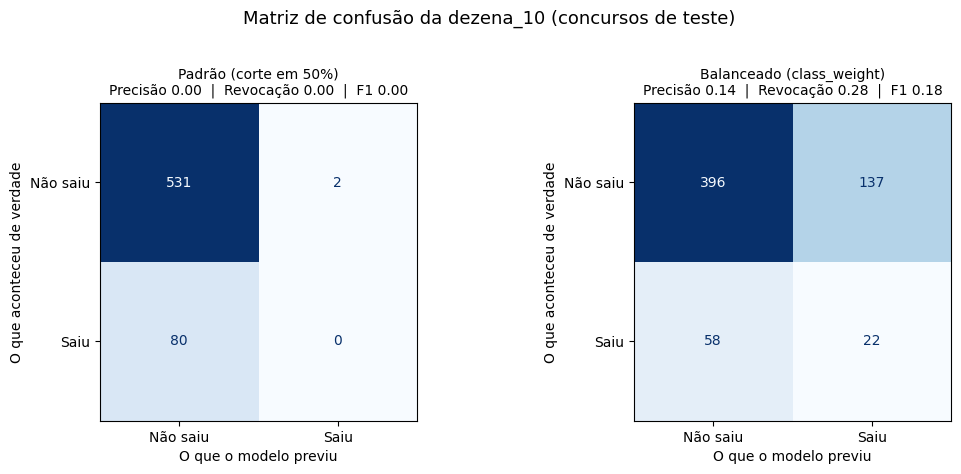

A dezena_10 saiu em 13.1% dos concursos de teste.
F1 de um "chute bobo" que sempre diz que a dezena sai: 0.23


In [ ]:
# MATRIZ DE CONFUSÃO + PRECISÃO, REVOCAÇÃO e F1 (exemplo com a dezena 10)
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, precision_score, recall_score, f1_score

alvo = 'dezena_10'
y_real = y_teste[alvo]

modelos = {
    'Padrão (corte em 50%)': LogisticRegression(max_iter=1000),
    'Balanceado (class_weight)': LogisticRegression(max_iter=1000, class_weight='balanced'),
}

fig, eixos = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, (nome, m) in zip(eixos, modelos.items()):
    m.fit(X_treino, y_treino[alvo])
    pred = m.predict(X_teste)
    ConfusionMatrixDisplay.from_predictions(
        y_real, pred, display_labels=['Não saiu', 'Saiu'],
        cmap='Blues', colorbar=False, ax=ax, values_format='d')
    p = precision_score(y_real, pred, zero_division=0)
    r = recall_score(y_real, pred, zero_division=0)
    f = f1_score(y_real, pred, zero_division=0)
    ax.set_title(f'{nome}\nPrecisão {p:.2f}  |  Revocação {r:.2f}  |  F1 {f:.2f}', fontsize=10)
    ax.set_xlabel('O que o modelo previu')
    ax.set_ylabel('O que aconteceu de verdade')

fig.suptitle(f'Matriz de confusão da {alvo} (concursos de teste)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

taxa = y_real.mean()
print(f'A {alvo} saiu em {taxa*100:.1f}% dos concursos de teste.')
print(f'F1 de um "chute bobo" que sempre diz que a dezena sai: {2*taxa/(1+taxa):.2f}')

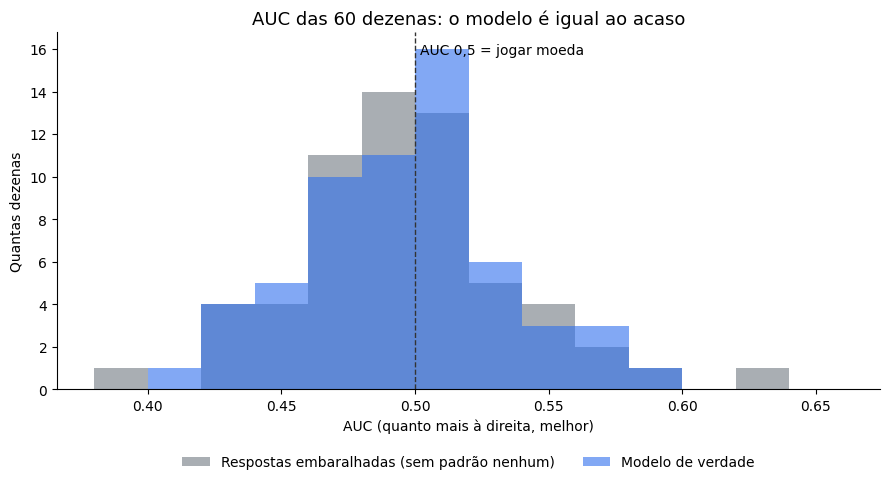

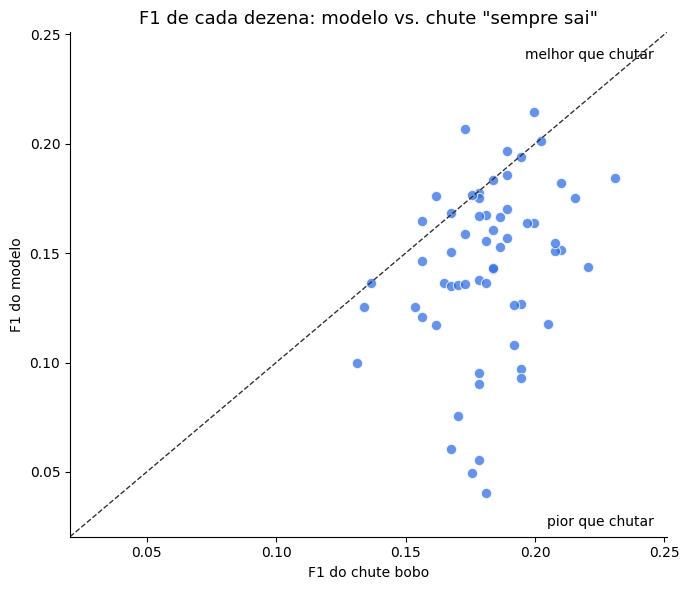

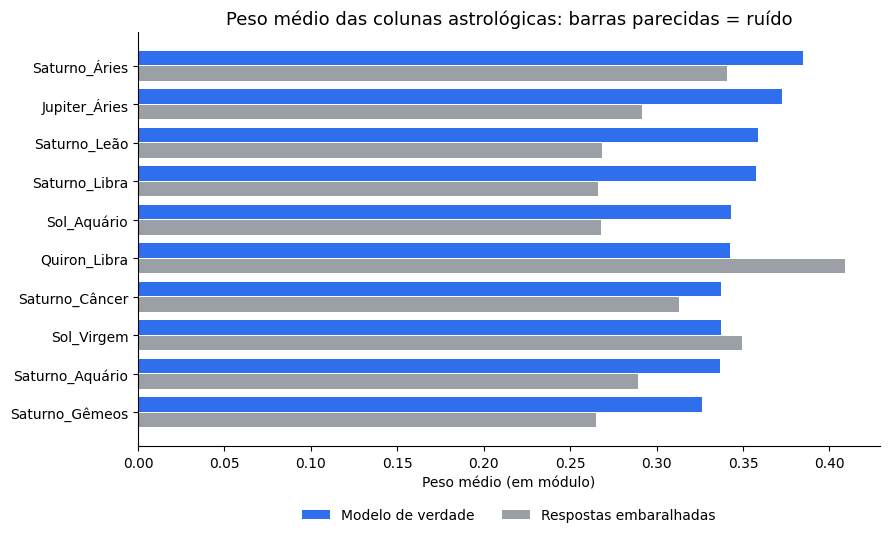

F1 médio do modelo: 0.143 | F1 médio do chute bobo: 0.182
Dezenas em que o modelo ficou acima do chute: 7 de 60


In [ ]:
# GRÁFICOS: o modelo de verdade vs. o acaso (usa auc, auc_aleatorio e comparacao das células anteriores)
AZUL, CINZA = '#2F6FED', '#9AA0A6'

# F1 de cada uma das 60 dezenas (modelo balanceado) e o F1 do "chute bobo" de cada uma
f1_modelo, f1_chute = [], []
for col in y.columns:
    m = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X_treino, y_treino[col])
    f1_modelo.append(f1_score(y_teste[col], m.predict(X_teste), zero_division=0))
    taxa = y_teste[col].mean()
    f1_chute.append(2 * taxa / (1 + taxa))
f1_modelo, f1_chute = np.array(f1_modelo), np.array(f1_chute)

def acabamento(ax):
    ax.spines[['top', 'right']].set_visible(False)

# GRÁFICO 1: AUC do modelo de verdade vs respostas embaralhadas
fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(0.38, 0.66, 15)
ax.hist(auc_aleatorio, bins=bins, color=CINZA, alpha=0.85, label='Respostas embaralhadas (sem padrão nenhum)')
ax.hist(auc, bins=bins, color=AZUL, alpha=0.6, label='Modelo de verdade')
ax.axvline(0.5, color='#333333', ls='--', lw=1)
ax.text(0.502, ax.get_ylim()[1] * 0.97, 'AUC 0,5 = jogar moeda', fontsize=10, va='top')
ax.set_title('AUC das 60 dezenas: o modelo é igual ao acaso', fontsize=13)
ax.set_xlabel('AUC (quanto mais à direita, melhor)'); ax.set_ylabel('Quantas dezenas')
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
acabamento(ax); plt.tight_layout(); plt.show()

# GRÁFICO 2: F1 do modelo vs F1 do chute bobo (cada ponto = uma dezena)
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(f1_chute, f1_modelo, color=AZUL, alpha=0.75, s=55, edgecolor='white', linewidth=0.8)
lim = [min(f1_chute.min(), f1_modelo.min()) - 0.02, max(f1_chute.max(), f1_modelo.max()) + 0.02]
ax.plot(lim, lim, color='#333333', ls='--', lw=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.text(lim[1] - 0.005, lim[1] - 0.012, 'melhor que chutar', ha='right', fontsize=10)
ax.text(lim[1] - 0.005, lim[0] + 0.005, 'pior que chutar', ha='right', fontsize=10)
ax.set_title('F1 de cada dezena: modelo vs. chute "sempre sai"', fontsize=13)
ax.set_xlabel('F1 do chute bobo'); ax.set_ylabel('F1 do modelo')
acabamento(ax); plt.tight_layout(); plt.show()

# GRÁFICO 3: pesos das 10 colunas astrológicas de maior peso, real vs embaralhado
fig, ax = plt.subplots(figsize=(9, 5.5))
top = comparacao.head(10).iloc[::-1]
pos = np.arange(len(top))
ax.barh(pos + 0.2, top['peso_medio_real'], height=0.38, color=AZUL, label='Modelo de verdade')
ax.barh(pos - 0.2, top['peso_medio_embaralhado'], height=0.38, color=CINZA, label='Respostas embaralhadas')
ax.set_yticks(pos); ax.set_yticklabels(top.index)
ax.set_title('Peso médio das colunas astrológicas: barras parecidas = ruído', fontsize=13)
ax.set_xlabel('Peso médio (em módulo)')
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2)
acabamento(ax); plt.tight_layout(); plt.show()

print(f'F1 médio do modelo: {f1_modelo.mean():.3f} | F1 médio do chute bobo: {f1_chute.mean():.3f}')
print(f'Dezenas em que o modelo ficou acima do chute: {(f1_modelo > f1_chute).sum()} de 60')